# Data Cleaning

Hey Ivette and Julia! As we discussed, I specifically loaded the bank-full.csv file and took the following steps for cleaning:


*   Checked for NA values (there were none to remove)
*   Converted all categorical variables to numeric
*   Defined X_bank_full and y_bank_full as features and target subsets of the bank_full dataframe

I figured for each algorithm I would let each of us do our own training and test set split, unless there's a good reason for us to use the same split. Let me know if I can answer any questions!

-Emmet

In [5]:
# From: https://archive.ics.uci.edu/dataset/222/bank+marketing
# pip install ucimlrepo

!pip install ucimlrepo

In [6]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [7]:
import pandas as pd

In [9]:
bank_full = pd.read_csv('/content/drive/MyDrive/Coursework 2025 WIN/IMT 574/Assignments/bank+marketing/bank/bank-full.csv', sep = ';')
print(bank_full.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [10]:
# Count NA/NULL values in each column (code from: https://www.geeksforgeeks.org/how-to-count-the-number-of-nan-values-in-pandas/)
column_nan_count = bank_full.isna().sum()
print("NaN count per column:")
print(column_nan_count)

# Appears to be no NA/NULL values in bank_full

NaN count per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [11]:
# Identify unique labels in categorical columns
for column in list(bank_full.columns):
  unique_values= bank_full[str(column)].unique()
  print('Unique values in ' + str(column) + ':' + str(unique_values))

Unique values in age:[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
Unique values in job:['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Unique values in marital:['married' 'single' 'divorced']
Unique values in education:['tertiary' 'secondary' 'unknown' 'primary']
Unique values in default:['no' 'yes']
Unique values in balance:[ 2143    29     2 ...  8205 14204 16353]
Unique values in housing:['yes' 'no']
Unique values in loan:['no' 'yes']
Unique values in contact:['unknown' 'cellular' 'telephone']
Unique values in day:[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
Unique values in month:['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr

In [12]:
# Convert categorical variables with integers
bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
                          'management', 'retired', 'self-employed', 'services',
                          'student', 'technician', 'unemployed', 'unknown'],
                           [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['marital'].replace(['single', 'married', 'divorced'],[1, 2, 3], inplace=True)
bank_full['education'].replace(['tertiary', 'secondary', 'unknown', 'primary'],[3, 2, 0, 1], inplace=True)
bank_full['default'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['housing'].replace(['yes', 'no'], [1, 0], inplace=True)
bank_full['loan'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['contact'].replace(['unknown', 'cellular', 'telephone'], [0, 1, 2], inplace=True)
bank_full['month'].replace(['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['poutcome'].replace(['unknown', 'failure', 'other', 'success'], [2, 0, 3, 1], inplace=True)
bank_full['y'].replace(['no', 'yes'], [0, 1], inplace=True)

<ipython-input-12-b8edec95c237>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
<ipython-input-12-b8edec95c237>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bank_full['job'].replace(['admin.', 'blue-collar', 'entrep

In [13]:
# Verifying that variable replacement worked
print(bank_full.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    5        2          3        0     2143        1     0        0   
1   44   10        1          2        0       29        1     0        0   
2   33    3        2          2        0        2        1     1        0   
3   47    2        2          0        0     1506        1     0        0   
4   33   12        1          0        0        1        0     0        0   

   day  month  duration  campaign  pdays  previous  poutcome  y  
0    5      5       261         1     -1         0         2  0  
1    5      5       151         1     -1         0         2  0  
2    5      5        76         1     -1         0         2  0  
3    5      5        92         1     -1         0         2  0  
4    5      5       198         1     -1         0         2  0  


In [16]:
# define features and targets dataframes
X_bank_full = bank_full[['age','job','marital','education','default','balance','housing','loan','contact','day','month','duration','campaign','pdays','previous','poutcome']]
y_bank_full = bank_full[['y']]

print(X_bank_full.head())
print(y_bank_full.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    5        2          3        0     2143        1     0        0   
1   44   10        1          2        0       29        1     0        0   
2   33    3        2          2        0        2        1     1        0   
3   47    2        2          0        0     1506        1     0        0   
4   33   12        1          0        0        1        0     0        0   

   day  month  duration  campaign  pdays  previous  poutcome  
0    5      5       261         1     -1         0         2  
1    5      5       151         1     -1         0         2  
2    5      5        76         1     -1         0         2  
3    5      5        92         1     -1         0         2  
4    5      5       198         1     -1         0         2  
   y
0  0
1  0
2  0
3  0
4  0


# Random Forest Model

In [14]:
# Steps for impementing random forest model
# - We have the dataset separated out into features and targets
# - Split into test set and training set
# - Decide which features to use or not -- could just use all of them??
# - Fit random forest model
# - Run predictions for random forest model
# - Calculate precision score for random forest model

In [40]:
# Divide dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_bank_full, y_bank_full, test_size=0.33, random_state=42)

# Note - I don't know if this is the best split; could try a different method e.g. k-fold, but I'm starting with this

In [18]:
# Visualizing X_train, X_test, y_train, and y_test to verify correct split
print(X_train.head())
print("Length of X_train is: " + str(len(X_train)))

print(X_test.head())
print("Length of X_test is: " + str(len(X_test)))

print(y_train.head())
print("Length of y_train is: " + str(len(y_train)))

print(y_test.head())
print("Length of y_test is: " +str(len(y_test)))

       age  job  marital  education  default  balance  housing  loan  contact  \
41031   29    4        1          3        0      453        0     0        1   
41950   55    8        2          2        0        0        0     0        1   
39883   56    8        3          2        0      935        0     0        1   
44938   47    4        1          3        0     3232        0     0        2   
42103   39   10        2          3        0      508        0     0        1   

       day  month  duration  campaign  pdays  previous  poutcome  
41031   13      8       126         2     -1         0         2  
41950   22     10       102         1    106         1         0  
39883    2      6       136         1     96         3         0  
44938    6     10       541         1    204         3         0  
42103    2     11       154         3     -1         0         2  
Length of X_train is: 30291
       age  job  marital  education  default  balance  housing  loan  contact  \
37

In [41]:
# Fit random forest model
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators = 100, max_depth = 7, min_samples_split=15, criterion = 'gini', random_state=42)
random_forest_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=7, min_samples_split=15, random_state=42)

In [42]:
# Run predictions for random forest model
y_pred_forest = random_forest_model.predict(X_test)
# print(y_pred_forest)

In [43]:
# Calculate precision score for random forest model
from sklearn.metrics import precision_score
random_forest_precision = precision_score(y_test, y_pred_forest)
print(random_forest_precision)

0.7145390070921985


# Random Forest Model with K-Fold Split

In [44]:
# import KFold from scikit-learn
from sklearn.model_selection import KFold

In [45]:
kf = KFold(n_splits=10, random_state=None, shuffle=False)

kf.get_n_splits(X_bank_full)

10

In [46]:
# Get 10 sets of kfold indices (from: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html)
KFold(n_splits=10, random_state=None, shuffle=False)

kfold_indices_dict = {}
for i, (train_index, test_index) in enumerate(kf.split(X_bank_full)):
    kfold_indices_dict[i] = [train_index, test_index]
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[ 4522  4523  4524 ... 45208 45209 45210]
  Test:  index=[   0    1    2 ... 4519 4520 4521]
Fold 1:
  Train: index=[    0     1     2 ... 45208 45209 45210]
  Test:  index=[4522 4523 4524 ... 9040 9041 9042]
Fold 2:
  Train: index=[    0     1     2 ... 45208 45209 45210]
  Test:  index=[ 9043  9044  9045 ... 13561 13562 13563]
Fold 3:
  Train: index=[    0     1     2 ... 45208 45209 45210]
  Test:  index=[13564 13565 13566 ... 18082 18083 18084]
Fold 4:
  Train: index=[    0     1     2 ... 45208 45209 45210]
  Test:  index=[18085 18086 18087 ... 22603 22604 22605]
Fold 5:
  Train: index=[    0     1     2 ... 45208 45209 45210]
  Test:  index=[22606 22607 22608 ... 27124 27125 27126]
Fold 6:
  Train: index=[    0     1     2 ... 45208 45209 45210]
  Test:  index=[27127 27128 27129 ... 31645 31646 31647]
Fold 7:
  Train: index=[    0     1     2 ... 45208 45209 45210]
  Test:  index=[31648 31649 31650 ... 36166 36167 36168]
Fold 8:
  Train: index=[    0     1 

In [47]:
# initialize empty dict
rf_model_preds_dict = {}
rf_model_y_test_dict = {}

for i in range(len(kfold_indices_dict)):
  # for each kfold get X_train, X_test, y_train, y_test out of indices generated above
  X_train = X_bank_full.iloc[kfold_indices_dict[i][0]]
  X_test = X_bank_full.iloc[kfold_indices_dict[i][1]]
  y_train = y_bank_full.iloc[kfold_indices_dict[i][0]]
  y_test = y_bank_full.iloc[kfold_indices_dict[i][1]]

  # Append y_test to random forest model y_test dict
  rf_model_y_test_dict[i] = y_test

  # fit each X_train and y_train to a random forest model
  rf_model = RandomForestClassifier(n_estimators = 100, max_depth = 7, min_samples_split=15, criterion = 'gini', random_state=42)
  rf_model.fit(X_train, y_train)

  # Run predictions for each random forest model
  y_pred_forest = rf_model.predict(X_test)

  # Add predictions to random forest model predictions dict
  rf_model_preds_dict[i] = y_pred_forest

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

In [48]:
# Troubleshooting - printing shape of test and training sets for just Fold 0
F0_X_train = X_bank_full.iloc[kfold_indices_dict[0][0]]
F0_X_test = X_bank_full.iloc[kfold_indices_dict[0][1]]
F0_y_train = y_bank_full.iloc[kfold_indices_dict[0][0]]
F0_y_test = y_bank_full.iloc[kfold_indices_dict[0][1]]

# print(F0_X_train.head())
print(F0_X_train.shape)

# print(F0_X_test.head())
print(F0_X_test.shape)

# print(F0_y_train.head())
print(F0_y_train.shape)

# print(F0_y_test.head())
print(len(F0_y_test))

(40689, 16)
(4522, 16)
(40689, 1)
4522


In [49]:
# Calculate precision scores for k-folds

# initialize empty dict
rf_model_pred_scores_dict = {}

for i in range(len(kfold_indices_dict)):
  # Calculate precision scores and add to random forest model prediction scores dict
  rf_precision = precision_score(rf_model_y_test_dict[i], rf_model_preds_dict[i])
  rf_model_pred_scores_dict[i] = rf_precision

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
# print precision scores for each k-fold
for i in rf_model_pred_scores_dict:
  print("Precision score for fold " + str(i) + ": " + str(rf_model_pred_scores_dict[i]))

Precision score for fold 0: 0.0
Precision score for fold 1: 0.3333333333333333
Precision score for fold 2: 0.2
Precision score for fold 3: 0.5714285714285714
Precision score for fold 4: 0.6486486486486487
Precision score for fold 5: 0.3888888888888889
Precision score for fold 6: 0.3347457627118644
Precision score for fold 7: 0.7079646017699115
Precision score for fold 8: 0.7049180327868853
Precision score for fold 9: 0.664


In [ ]:
# Now getting closer to 70% as highest score

# Exploratory Data Analysis

In [30]:
# exploratory data analysis for feature selection

# Summarize data
print(bank_full.describe())

# Test to estimate multicollinearity (look into your R files)
#

                age           job       marital     education       default  \
count  45211.000000  45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210      5.339762      1.832275      2.060516      0.018027   
std       10.618762      3.272657      0.608230      0.778704      0.133049   
min       18.000000      1.000000      1.000000      0.000000      0.000000   
25%       33.000000      2.000000      1.000000      2.000000      0.000000   
50%       39.000000      5.000000      2.000000      2.000000      0.000000   
75%       48.000000      8.000000      2.000000      3.000000      0.000000   
max       95.000000     12.000000      3.000000      3.000000      1.000000   

             balance       housing          loan       contact           day  \
count   45211.000000  45211.000000  45211.000000  45211.000000  45211.000000   
mean     1362.272058      0.555838      0.160226      0.776293     15.806419   
std      3044.765829      0.496878      0.366820

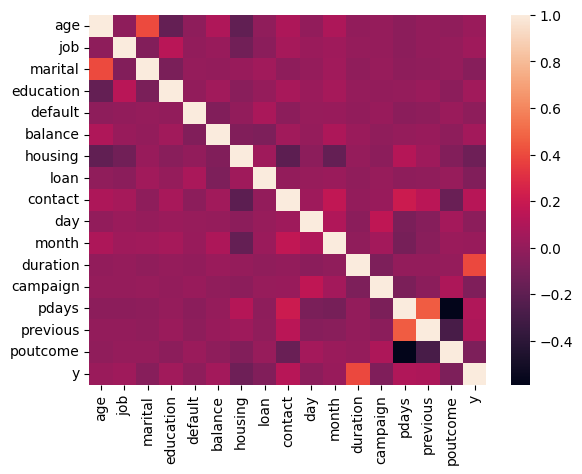

In [31]:
# Correlation heat map (code example from: https://www.geeksforgeeks.org/how-to-create-a-seaborn-correlation-heatmap-in-python/)

# Import modules
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

# Plotting correlation heatmap
bank_full_heatmap = sb.heatmap(bank_full.corr(numeric_only=True))

# Displaying heatmap
plt.show()

# Okay, so the variables that seem to be more correlated are:
# Positively correlated:
# - Age and marital (positively correlated)
# - Duration and y/target/success of marketing campaign
# - pdays and previous
# Negatively correlated:
# - pdays and poutcome (strongly negatively correlated)
# - Age and education (slightly negatively correlated)
# - Age and housing (slightly negatively correlated)
# - Housing and month (negatively correlated)
# - Housing and contact (negatively correlated)
# - previous and poutcome (strongly negatively correlated)

# Random Forest Model V2 -- Selected Features

Selected features include:
- duration
- housing
- pdays
- month
- poutcome
- age

In [32]:
# define features and targets dataframes
X_bank_full_V2 = bank_full[['age','housing','month','duration','pdays','poutcome']]
y_bank_full_V2 = bank_full[['y']]

In [33]:
X_bank_full_V2.head()

,age,housing,month,duration,pdays,poutcome
0,58,1,5,261,-1,2
1,44,1,5,151,-1,2
2,33,1,5,76,-1,2
3,47,1,5,92,-1,2
4,33,0,5,198,-1,2


In [34]:
# Divide dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train_V2, X_test_V2, y_train_V2, y_test_V2 = train_test_split(X_bank_full_V2, y_bank_full_V2, test_size=0.33, random_state=42)

# Note - I don't know if this is the best split; could try a different method e.g. k-fold, but I'm starting with this

In [51]:
# Fit random forest model V2
from sklearn.ensemble import RandomForestClassifier
random_forest_model_V2 = RandomForestClassifier(n_estimators = 100, max_depth = 7, min_samples_split=15, criterion = 'gini', random_state=42)
random_forest_model_V2.fit(X_train_V2, y_train_V2)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=7, min_samples_split=15, random_state=42)

In [52]:
# Run predictions for random forest model V2
y_pred_forest_V2 = random_forest_model_V2.predict(X_test_V2)

In [53]:
print(y_pred_forest_V2)

[0 0 0 ... 0 0 0]


In [54]:
# Calculate precision score for random forest model
from sklearn.metrics import precision_score
random_forest_precision_V2 = precision_score(y_test_V2, y_pred_forest_V2)
print(random_forest_precision_V2)

0.6529477196885428


In [ ]:
# OK - limiting max depth to 7 and setting random state = 42 increased the precision score by about 5%
# Increasing the minimum number of samples further increased the precision score by about 1%